# Query Cloud SQL Database

Connect to the remote tracking analytics database via Cloud SQL Proxy and explore the data.

## Prerequisites

### 1. Install gcloud CLI
```bash
# macOS
brew install google-cloud-sdk

# Or download from: https://cloud.google.com/sdk/docs/install
```

### 2. Install Cloud SQL Auth Proxy
```bash
# macOS (Apple Silicon)
curl -o cloud-sql-proxy https://storage.googleapis.com/cloud-sql-connectors/cloud-sql-proxy/v2.14.3/cloud-sql-proxy.darwin.arm64
chmod +x cloud-sql-proxy
sudo mv cloud-sql-proxy /usr/local/bin/

# macOS (Intel)
curl -o cloud-sql-proxy https://storage.googleapis.com/cloud-sql-connectors/cloud-sql-proxy/v2.14.3/cloud-sql-proxy.darwin.amd64
chmod +x cloud-sql-proxy
sudo mv cloud-sql-proxy /usr/local/bin/
```

### 3. Authenticate with Google Cloud
```bash
# Login
gcloud auth login
gcloud auth application-default login

# Set project
gcloud config set project collab-data-463313
```

### 4. Install the package (from current branch)
```bash
pip install "collab-env[db] @ git+https://github.com/BasisResearch/collab-environment.git@db-eda-dashboard"
```

### 5. Start the Cloud SQL Proxy (in a separate terminal)
```bash
# From the repo root:
source scripts/deploy/config.sh
./scripts/deploy/start_proxy.sh

# Or manually:
cloud-sql-proxy collab-data-463313:us-central1:spatial-analysis-db --port 5433
```

Keep the proxy running while using this notebook.

## Setup Environment Variables

In [1]:
import os
import subprocess

# Get password from Secret Manager
result = subprocess.run(
    ["gcloud", "secrets", "versions", "access", "latest", "--secret=postgres-password"],
    capture_output=True, text=True
)
if result.returncode != 0:
    raise RuntimeError(f"Failed to get password: {result.stderr}")

# Set environment variables for database connection
os.environ["DB_BACKEND"] = "postgres"
os.environ["POSTGRES_HOST"] = "localhost"
os.environ["POSTGRES_PORT"] = "5433"
os.environ["POSTGRES_DB"] = "tracking_analytics"
os.environ["POSTGRES_USER"] = "postgres"
os.environ["POSTGRES_PASSWORD"] = result.stdout.strip()

print("Environment configured for Cloud SQL via proxy on localhost:5433")

Environment configured for Cloud SQL via proxy on localhost:5433


## Connect to Database

In [2]:
from collab_env.data.db.query_backend import QueryBackend

# Initialize query backend (reads config from environment)
query = QueryBackend()
print("Connected to Cloud SQL database")

2026-01-07 16:07:10 | INFO     | collab_env.data.db.db_loader:connect:162 - Connected to PostgreSQL: tracking_analytics
2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:__init__:85 - Loaded queries from /Users/dima/git/collab-environment/collab_env/data/db/queries using psycopg2 adapter


Connected to Cloud SQL database


## Explore Sessions and Episodes

In [3]:
# Get all categories
categories = query.get_categories()
print("Available categories:")
categories

2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_categories' with params: {}
2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_categories' completed in 0.078s: 4 rows returned


Available categories:


,category_id,category_name,description
0,boids_2d_rollout,2D Boids GNN Rollout,GNN model predictions on 2D boids test data
1,boids_2d,2D Boids Simulations,Sessions from 2D boid simulations
2,boids_3d,3D Boids Simulations,Sessions from 3D boid simulations
3,tracking_csv,Real-World Tracking,Sessions from video tracking (CSV data)


In [4]:
# Get sessions (optionally filter by category)
sessions = query.get_sessions()
print(f"Found {len(sessions)} sessions:")
sessions[["session_id", "session_name", "category_id"]]

2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_sessions' with params: {'category_id': None}
2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_sessions' completed in 0.116s: 19 rows returned


Found 19 sessions:


,session_id,session_name,category_id
0,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,GNN Rollout: boid_food_strong_vpluspplus_a_n0_...,boids_2d_rollout
1,rollout-boid_food_independent_vpluspplus_a_n0_...,GNN Rollout: boid_food_independent_vpluspplus_...,boids_2d_rollout
2,rollout-boid_food_basic_vpluspplus_a_n0_h1_vr0...,GNN Rollout: boid_food_basic_vpluspplus_a_n0_h...,boids_2d_rollout
3,rollout-boid_food_basic_vpluspplus_a_n0_h1_vr0...,GNN Rollout fix2: boid_food_basic_vpluspplus_a...,boids_2d_rollout
4,rollout-boid_food_independent_vpluspplus_a_n0....,GNN Rollout fix2: boid_food_independent_vplusp...,boids_2d_rollout
5,rollout-boid_food_strong_vpluspplus_a_n0.005_h...,GNN Rollout fix2: boid_food_strong_vpluspplus_...,boids_2d_rollout
6,session-hackathon-boid-small-200-align-cohesio...,hackathon-boid-small-200-align-cohesion_sim_ru...,boids_3d
7,session-hackathon-homogenous-0.02-200-20-0.0-0...,hackathon-homogenous-0.02-200-20-0.0-0.0-sim_r...,boids_3d
8,session-hackathon-random-1-small-200-sim_run-s...,hackathon-random-1-small-200-sim_run-started-2...,boids_3d
9,session-hackathon-small-small-200-cohesion-sim...,hackathon-small-small-200-cohesion-sim_run-sta...,boids_3d


In [5]:
# Select a session and get its episodes
session_id = sessions.iloc[0]["session_id"]
print(f"Selected session: {session_id}")

episodes = query.get_episodes(session_id)
print(f"\nFound {len(episodes)} episodes:")
episodes[["episode_id", "episode_number", "num_frames", "num_agents", "frame_rate"]]

2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_episodes' with params: {'session_id': 'rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown'}


Selected session: rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown


2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_episodes' completed in 0.155s: 600 rows returned



Found 600 episodes:


,episode_id,episode_number,num_frames,num_agents,frame_rate
0,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,0,97,21,1.0
1,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,1,97,21,1.0
2,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,2,97,21,1.0
3,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,3,97,21,1.0
4,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,4,97,21,1.0
...,...,...,...,...,...
595,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,595,97,21,1.0
596,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,596,97,21,1.0
597,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,597,97,21,1.0
598,rollout-boid_food_strong_vpluspplus_a_n0_h1_vr...,598,97,21,1.0


## Query Tracks

In [6]:
# Get tracks for an episode (first 100 frames)
episode_id = episodes.iloc[0]["episode_id"]
print(f"Getting tracks for episode: {episode_id}")

tracks = query.get_episode_tracks(
    episode_id=episode_id,
    start_time=0,
    end_time=100
)
print(f"\nLoaded {len(tracks)} track points")
tracks.head(10)

2026-01-07 16:07:10 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_episode_tracks' with params: {'episode_id': 'rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown-0000-actual', 'start_time': 0, 'end_time': 100, 'agent_type': 'agent'}
2026-01-07 16:07:11 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_episode_tracks' completed in 0.118s: 1940 rows returned


Getting tracks for episode: rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown-0000-actual

Loaded 1940 track points


,agent_id,time_index,x,y,z,v_x,v_y,v_z,speed
0,0,0,229.704697,58.595470,None,-5.393005,-4.462669,None,6.999995
1,1,0,290.361786,6.335892,None,-6.923401,1.032695,None,6.999996
2,2,0,213.122482,463.195770,None,2.413010,-6.570953,None,7.000003
3,3,0,128.084381,36.116634,None,3.232834,-6.208765,None,6.999998
4,4,0,52.135567,201.556259,None,1.739902,-0.730545,None,1.887050
5,5,0,165.632996,8.682363,None,-0.084961,-4.525819,None,4.526617
6,6,0,327.016144,11.077126,None,-6.965576,0.693343,None,6.999998
7,7,0,124.487625,205.590729,None,-1.766724,0.523621,None,1.842686
8,8,0,331.743805,372.366943,None,4.741272,-0.785522,None,4.805903
9,9,0,435.434753,391.073914,None,-1.792358,3.870361,None,4.265237


In [7]:
# Basic track statistics
print(f"Time range: {tracks['time_index'].min()} - {tracks['time_index'].max()}")
print(f"Unique agents: {tracks['agent_id'].nunique()}")
print(f"\nSpeed statistics:")
tracks["speed"].describe()

Time range: 0 - 96
Unique agents: 20

Speed statistics:


count    1940.000000
mean        2.926194
std         2.366201
min         0.012640
25%         0.683388
50%         2.533038
75%         4.501801
max         7.000029
Name: speed, dtype: float64

## Visualize Tracks

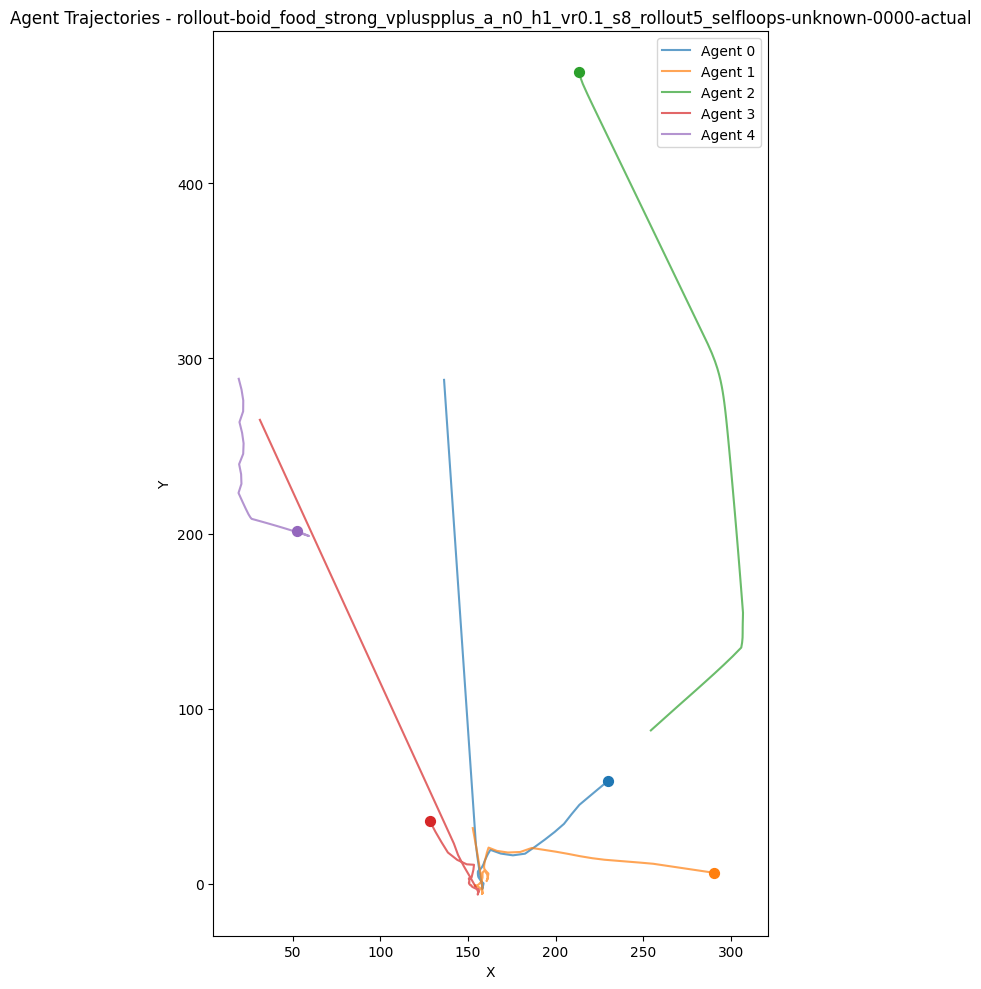

In [8]:
import matplotlib.pyplot as plt

# Plot XY trajectories for first 5 agents
fig, ax = plt.subplots(figsize=(10, 10))

agent_ids = tracks["agent_id"].unique()[:5]
for agent_id in agent_ids:
    agent_tracks = tracks[tracks["agent_id"] == agent_id]
    ax.plot(agent_tracks["x"], agent_tracks["y"], "-", alpha=0.7, label=f"Agent {agent_id}")
    # Mark start position
    ax.scatter(agent_tracks["x"].iloc[0], agent_tracks["y"].iloc[0], s=50, marker="o")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title(f"Agent Trajectories - {episode_id}")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

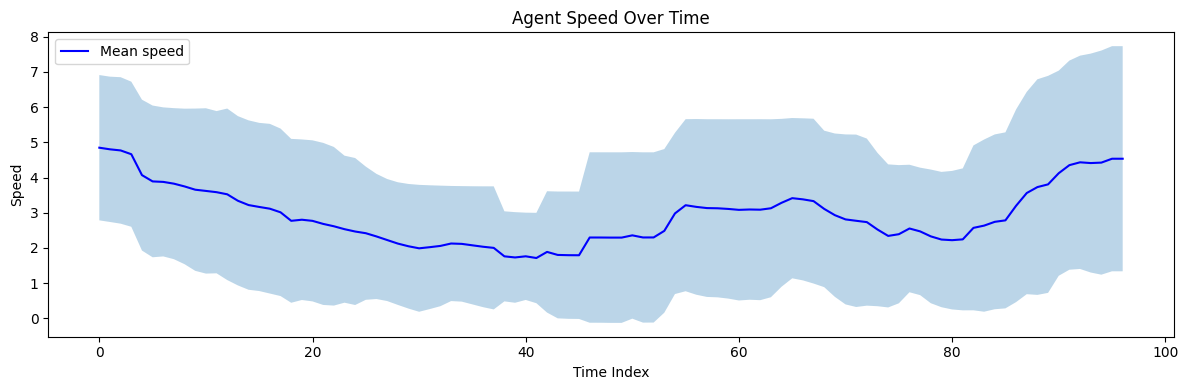

In [9]:
# Speed over time for all agents
fig, ax = plt.subplots(figsize=(12, 4))

# Compute mean speed per time step
speed_by_time = tracks.groupby("time_index")["speed"].agg(["mean", "std"])
ax.fill_between(
    speed_by_time.index,
    speed_by_time["mean"] - speed_by_time["std"],
    speed_by_time["mean"] + speed_by_time["std"],
    alpha=0.3
)
ax.plot(speed_by_time.index, speed_by_time["mean"], "b-", label="Mean speed")

ax.set_xlabel("Time Index")
ax.set_ylabel("Speed")
ax.set_title("Agent Speed Over Time")
ax.legend()
plt.tight_layout()
plt.show()

## Spatial Heatmap

In [10]:
# Get spatial heatmap (binned positions)
heatmap = query.get_spatial_heatmap(
    episode_id=episode_id,
    bin_size=20.0
)
print(f"Heatmap has {len(heatmap)} bins")
heatmap.head()

2026-01-07 16:07:11 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_spatial_heatmap_episode' with params: {'episode_id': 'rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown-0000-actual', 'bin_size': 20.0, 'start_time': None, 'end_time': None, 'agent_type': 'agent', 'min_count': 1}
2026-01-07 16:07:11 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_spatial_heatmap_episode' completed in 0.079s: 207 rows returned


Heatmap has 207 bins


,x_bin,y_bin,z_bin,density,avg_vx,avg_vy,avg_vz
0,0.0,220.0,None,2,2.001506,5.538452,None
1,20.0,200.0,None,34,-0.610308,0.544680,None
2,20.0,220.0,None,2,-0.663492,5.612450,None
3,20.0,240.0,None,6,-1.811501,6.204732,None
4,20.0,260.0,None,3,-1.276601,6.244843,None


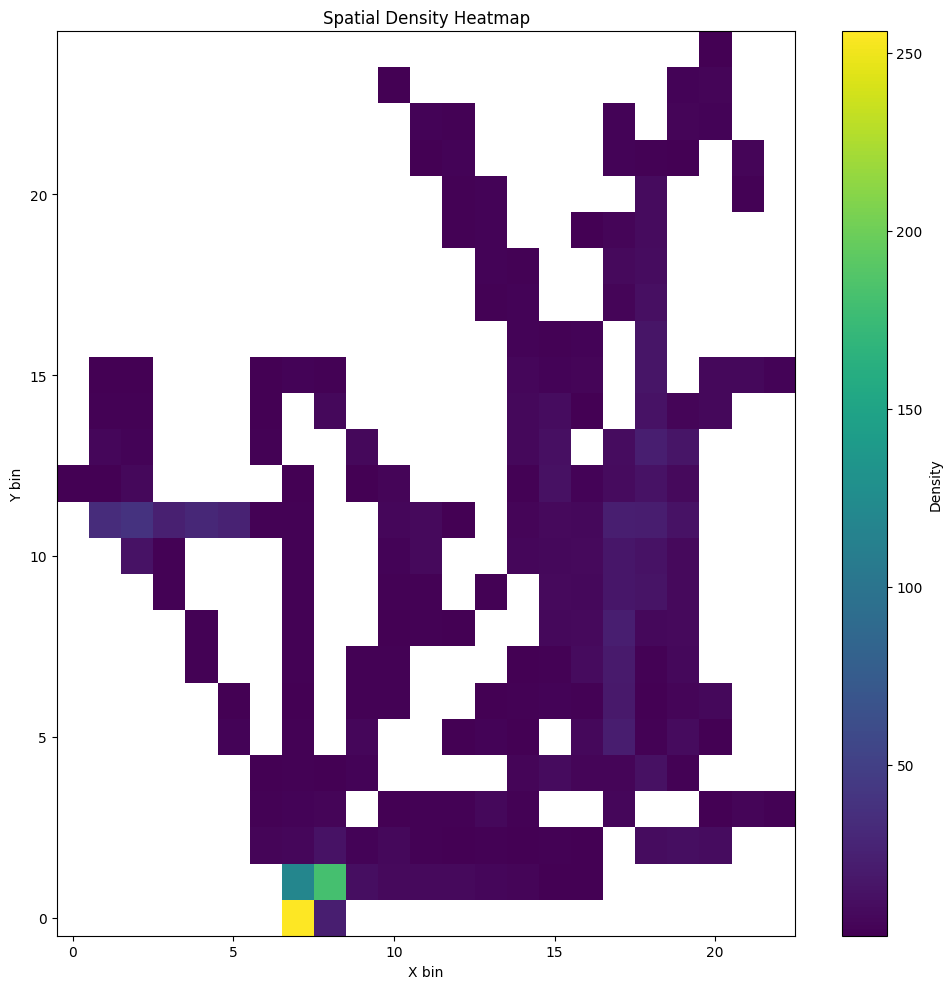

In [11]:
# Plot 2D heatmap (XY)
import numpy as np

# Aggregate z dimension
heatmap_2d = heatmap.groupby(["x_bin", "y_bin"])["density"].sum().reset_index()

# Create 2D grid
pivot = heatmap_2d.pivot(index="y_bin", columns="x_bin", values="density")

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(pivot.values, origin="lower", cmap="viridis", aspect="auto")
ax.set_xlabel("X bin")
ax.set_ylabel("Y bin")
ax.set_title("Spatial Density Heatmap")
plt.colorbar(im, ax=ax, label="Density")
plt.tight_layout()
plt.show()

## Extended Properties

In [12]:
# Get available extended properties for this episode
props = query.get_available_properties(episode_id)
print("Available extended properties:")
props[["property_id", "property_name", "data_type", "unit"]]

2026-01-07 16:07:11 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_available_properties_episode' with params: {'episode_id': 'rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown-0000-actual', 'agent_type': 'agent'}
2026-01-07 16:07:11 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_available_properties_episode' completed in 0.092s: 3 rows returned


Available extended properties:


,property_id,property_name,data_type,unit
0,acceleration_x,Acceleration X,float,scene_units/frame^2
1,acceleration_y,Acceleration Y,float,scene_units/frame^2
2,distance_to_food,Distance to Food,float,scene_units


2026-01-07 16:07:11 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_property_distributions_episode' with params: {'episode_id': 'rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown-0000-actual', 'start_time': None, 'end_time': None, 'agent_type': 'agent'}
2026-01-07 16:07:11 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_property_distributions_episode' completed in 0.096s: 5820 rows returned


Getting distribution for: acceleration_x

Distribution statistics:
  Count: 1940
  Mean: -0.014
  Std: 0.470
  Min: -6.189
  Max: 4.443


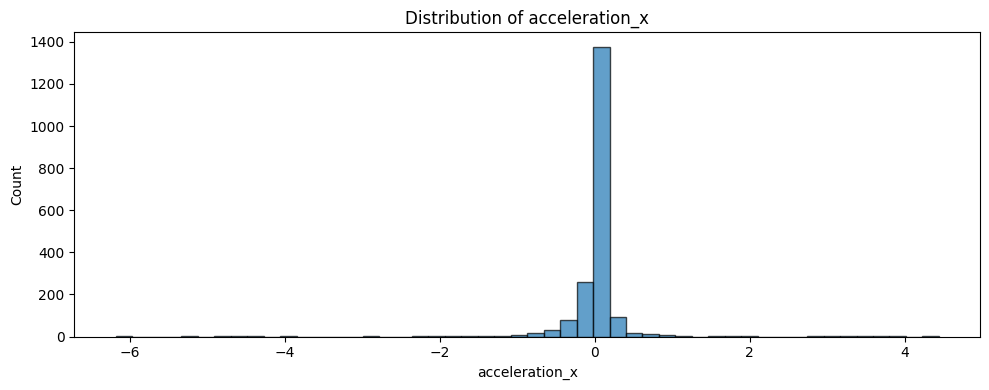

In [13]:
# Get distribution of a property (if any exist)
if len(props) > 0:
    property_id = props.iloc[0]["property_id"]
    print(f"Getting distribution for: {property_id}")
    
    dist = query.get_property_distributions(
        episode_id=episode_id,
        property_ids=[property_id]
    )
    
    if len(dist) > 0:
        print(f"\nDistribution statistics:")
        print(f"  Count: {len(dist)}")
        print(f"  Mean: {dist['value_float'].mean():.3f}")
        print(f"  Std: {dist['value_float'].std():.3f}")
        print(f"  Min: {dist['value_float'].min():.3f}")
        print(f"  Max: {dist['value_float'].max():.3f}")
        
        # Plot histogram
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(dist["value_float"], bins=50, edgecolor="black", alpha=0.7)
        ax.set_xlabel(property_id)
        ax.set_ylabel("Count")
        ax.set_title(f"Distribution of {property_id}")
        plt.tight_layout()
        plt.show()
else:
    print("No extended properties available for this episode")

2026-01-07 16:07:12 | INFO     | collab_env.data.db.query_backend:_execute_query:110 - Executing query 'get_extended_properties_timeseries' with params: {'episode_id': 'rollout-boid_food_strong_vpluspplus_a_n0_h1_vr0.1_s8_rollout5_selfloops-unknown-0000-actual', 'window_size': 10, 'start_time': None, 'end_time': None, 'agent_type': 'agent', 'lower_quantile': 0.1, 'upper_quantile': 0.9}
2026-01-07 16:07:12 | INFO     | collab_env.data.db.query_backend:_execute_query:138 - Query 'get_extended_properties_timeseries' completed in 0.088s: 30 rows returned


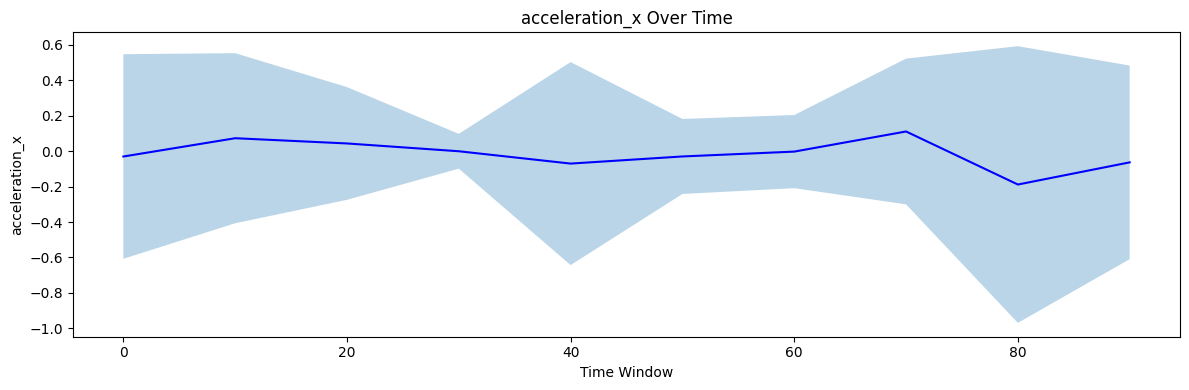

In [14]:
# Get time series of extended properties (windowed)
if len(props) > 0:
    property_id = props.iloc[0]["property_id"]
    
    timeseries = query.get_extended_properties_timeseries(
        episode_id=episode_id,
        window_size=10,
        property_ids=[property_id]
    )
    
    if len(timeseries) > 0:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.fill_between(
            timeseries["time_window"],
            timeseries["avg_value"] - timeseries["std_value"],
            timeseries["avg_value"] + timeseries["std_value"],
            alpha=0.3
        )
        ax.plot(timeseries["time_window"], timeseries["avg_value"], "b-")
        ax.set_xlabel("Time Window")
        ax.set_ylabel(property_id)
        ax.set_title(f"{property_id} Over Time")
        plt.tight_layout()
        plt.show()

## Cleanup

In [15]:
# Close database connection
query.close()
print("Connection closed")

2026-01-07 16:07:12 | INFO     | collab_env.data.db.query_backend:close:89 - Closing database connection...
2026-01-07 16:07:12 | INFO     | collab_env.data.db.db_loader:close:170 - Database connection closed


Connection closed


## Troubleshooting

### "Connection refused" error
- Make sure Cloud SQL Proxy is running in another terminal
- Check that port 5433 is not in use: `lsof -i :5433`

### "Permission denied" for secrets
- Run `gcloud auth application-default login`
- Verify project: `gcloud config get-value project`

### Package import errors
- Ensure you installed from the correct branch:
  ```bash
  pip install "collab-env[db] @ git+https://github.com/BasisResearch/collab-environment.git@db-eda-dashboard"
  ```